# Heart Disease Prediction Using Machine Learning

## Business Understanding

Heart disease is one of the leading causes of death worldwide. Early identification of high-risk patients can help healthcare professionals provide timely treatment and reduce the likelihood of severe complications.

The goal of this project is to develop a machine learning model capable of predicting the presence of heart disease using patient clinical and demographic information. Since failing to identify a patient with heart disease can have serious consequences, Recall and ROC-AUC are considered the most important evaluation metrics.


## Project Objective

The objective of this project is to develop a machine learning-based system for predicting heart disease using clinical and demographic patient data. Multiple machine learning algorithms, including Logistic Regression, Decision Tree, Random Forest, and XGBoost, are evaluated and compared using metrics such as Accuracy, Recall, F1-Score, and ROC-AUC. The primary goal is to identify high-risk patients accurately and support early medical screening while minimizing missed heart disease cases.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("heart.csv")

In [3]:
# Small Explanation
# Feature	Type	Why
# Sex	Categorical	Male/Female
# ChestPainType	Categorical	Different chest pain groups
# FastingBS	Categorical	0 or 1
# RestingECG	Categorical	ECG categories
# ExerciseAngina	Categorical	Yes/No
# ST_Slope	Categorical	Up/Flat/Down
# HeartDisease	Categorical	Target class (0/1)

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [6]:
df.shape

(918, 12)

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [12]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

# Exploratory Data Analysis Insights

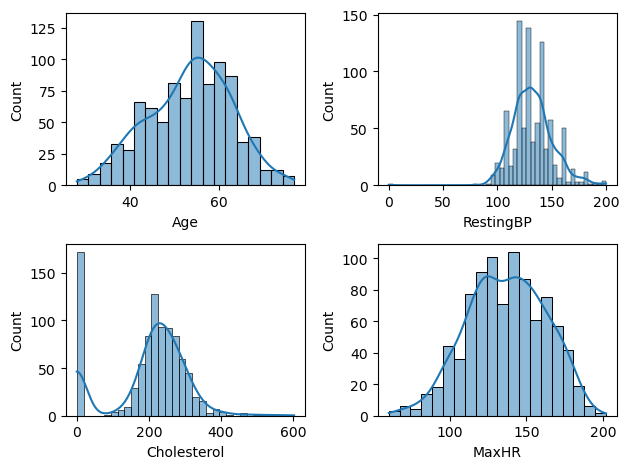

In [14]:
def plotting(var,num): 
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [15]:
ch_mean=df.loc[df["Cholesterol"] !=0,"Cholesterol"].mean().round()
df["Cholesterol"]=df["Cholesterol"].replace(0,ch_mean)
ch_mean

np.float64(245.0)

In [16]:
resting_bp_mean=df.loc[df["RestingBP"]!=0,"RestingBP"].mean().round()
df["RestingBP"]=df["RestingBP"].replace(0,resting_bp_mean)

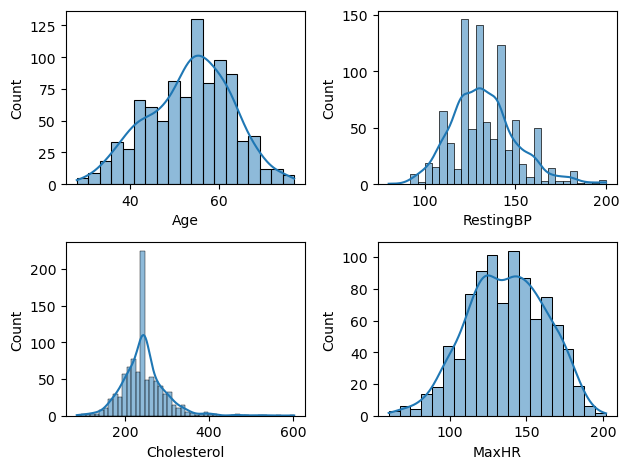

In [17]:
def plotting(var,num): 
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

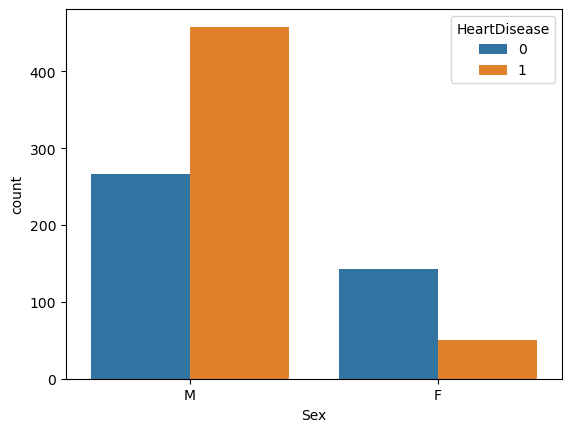

In [18]:
sns.countplot(x=df["Sex"],hue=df["HeartDisease"])

Observation:

Male patients exhibit a considerably higher number of heart disease cases than female patients.
This suggests gender may be an important predictor of cardiovascular risk.

<Axes: xlabel='ChestPainType', ylabel='count'>

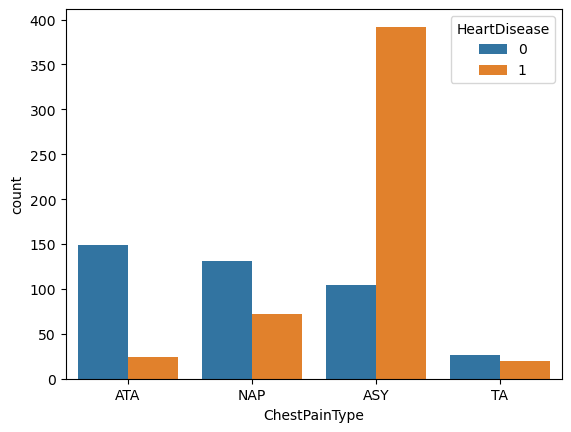

In [19]:
sns.countplot(x=df["ChestPainType"],hue=df["HeartDisease"])

Observation:

Certain chest pain categories show much higher proportions of heart disease.
Chest pain type appears to be one of the strongest categorical predictors.

<Axes: xlabel='FastingBS', ylabel='count'>

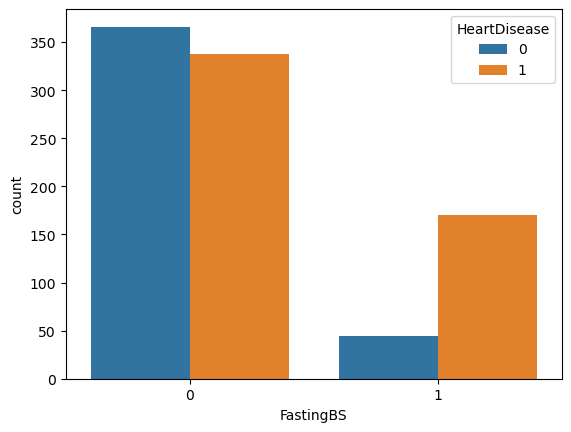

In [20]:
sns.countplot(x=df["FastingBS"],hue=df["HeartDisease"])

Observation:

Patients with elevated fasting blood sugar levels show a greater prevalence of heart disease.
This suggests a possible relationship between diabetes-related indicators and cardiovascular risk.

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

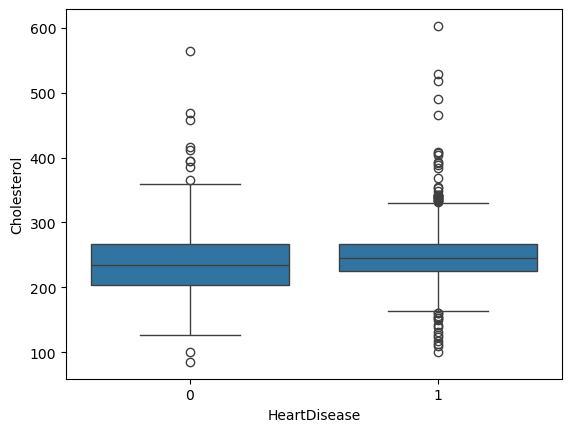

In [21]:
sns.boxplot(x="HeartDisease",y="Cholesterol",data=df)

Observation:

Several outliers are visible in resting blood pressure.
However, since these values may represent actual medical conditions, they should be investigated rather than automatically removed.

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

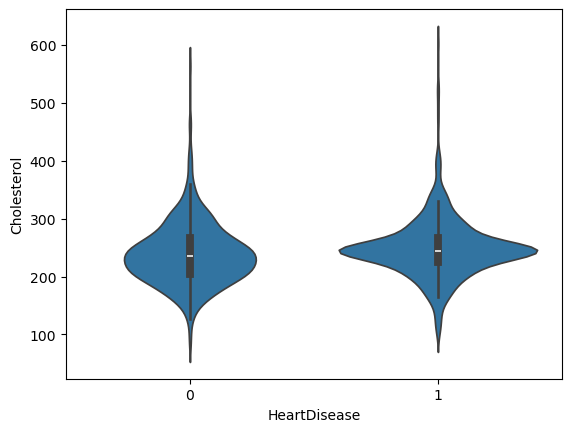

In [22]:
sns.violinplot(x="HeartDisease",y="Cholesterol",data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

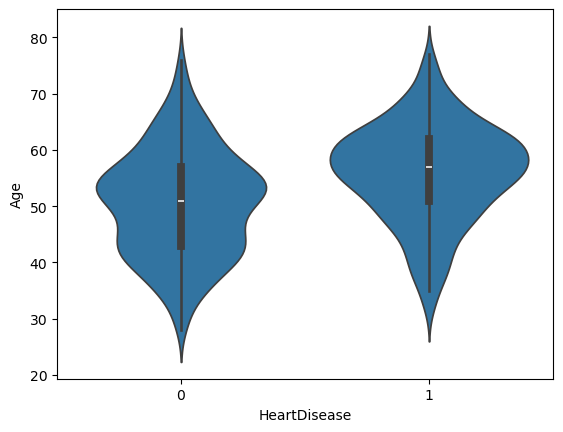

In [23]:
sns.violinplot(x="HeartDisease",y="Age",data=df)

Observation:

The distribution of resting blood pressure differs slightly between patients with and without heart disease.
Patients with heart disease tend to have a wider spread of values.

<Axes: >

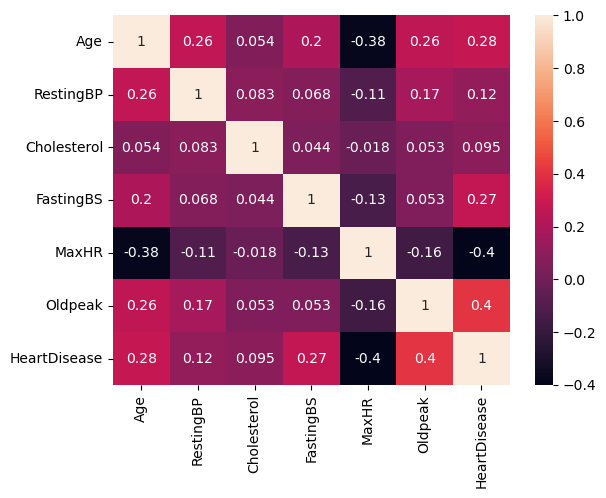

In [24]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Observation:

Oldpeak shows a strong positive correlation with heart disease.
MaxHR shows a negative correlation with heart disease.
Age has a moderate positive relationship with heart disease risk.
Most features are not highly correlated with each other, reducing concerns about multicollinearity.

# Data preprocessing and cleaning

In [25]:
cat_cols = ["Sex","ChestPainType","RestingECG","ExerciseAngina","ST_Slope"]

In [26]:
num_cols= ["Age","RestingBP","Cholesterol","FastingBS","MaxHR","Oldpeak"]

In [27]:
df_encode=pd.get_dummies(df,drop_first=True)

In [28]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [29]:
df_encode.astype(int)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [30]:
# Easy Memory Trick
# 1. Split Data
# 2. Create Scaler
# 3. fit_transform() on Train
# 4. transform() on Test
# 5. Train Model
# 6. Evaluate Model

# Whenever you use StandardScaler, remember:

# Train learns (fit), Test only follows (transform).

# That's one of the most important concepts in machine learning preprocessing. 🚀

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x=df_encode.drop("HeartDisease",axis=1)
y=df_encode["HeartDisease"]

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

numerical_cols= ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler=StandardScaler()

X_train[numerical_cols]=scaler.fit_transform(X_train[numerical_cols])

X_test[numerical_cols]=scaler.transform(X_test[numerical_cols])

In [32]:
X_train.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,-0.541137,1,-0.324520,0.317046,True,True,False,False,False,True,True,True,False
486,0.122028,-1.266031,-0.596569,1,1.689837,-0.440356,True,True,False,False,False,True,False,False,True
117,0.546020,-0.159102,1.694652,1,-0.247045,0.601071,False,False,False,False,False,True,True,True,False
361,-0.725956,1.501291,-0.023764,0,-0.479470,-0.819056,True,False,False,False,True,False,True,True,False
296,-0.407962,0.671094,-0.023764,1,0.101594,-0.156330,True,False,False,False,True,False,True,True,False


# Logistic Regression Model

In [33]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

y_predict=model.predict(X_test)

y_prob_lr = model.predict_proba(X_test)[:,1]

# Evaluation 

### Accuracy score 

In [34]:
from sklearn.metrics import accuracy_score

accuracy= accuracy_score(y_test,y_predict)
print("accuracy: ",accuracy)

accuracy:  0.8913043478260869


### Classification report

In [35]:
from sklearn.metrics import classification_report
Classificationreport=classification_report(y_test,y_predict)
print(Classificationreport)

              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### Confusion report

In [36]:
from sklearn.metrics import confusion_matrix
Confusionmatrix=confusion_matrix(y_test,y_predict)
print("Confusion matrix:",Confusionmatrix)

Confusion matrix: [[71 11]
 [ 9 93]]


### ROC-AUC Score

In [37]:
from sklearn.metrics import roc_auc_score
ROC_AUC=roc_auc_score(y_test,y_prob_lr)
print("ROC_AUC: ",ROC_AUC)

# ROC-AUC is designed to measure how well the model ranks positive cases higher than negative cases.

ROC_AUC:  0.9341224294595887


### Logistic regression results  
Logistic Regression achieved strong predictive performance with an accuracy of 89.13% and an ROC-AUC score of 0.9341. 
The model demonstrated excellent discrimination between positive and negative classes while maintaining a high recall of 91%, making it effective for identifying patients at risk of heart disease.

# Decision Tree Model

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt=dt.predict(X_test)

y_prob_dt=dt.predict_proba(X_test)[:,1]

## Evalutaion

In [39]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_auc_score)

print("Accuracy:",accuracy_score(y_test,y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test,y_pred_dt))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_dt))

Accuracy: 0.75

Confusion Matrix:
[[60 22]
 [24 78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        82
           1       0.78      0.76      0.77       102

    accuracy                           0.75       184
   macro avg       0.75      0.75      0.75       184
weighted avg       0.75      0.75      0.75       184


ROC-AUC: 0.7482065997130559


## Hyperparameter Tuning (ROC-AUC and Recall) & Pre-pruning

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid={
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [41]:
dt=DecisionTreeClassifier(random_state=42)

grid=GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,scoring="roc_auc",n_jobs=-1)

grid.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [42]:
print("Best Paramaters:")
print(grid.best_params_)
print("\nBest Score:")
print(grid.best_score_)

Best Paramaters:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best Score:
0.8879240251868978


In [43]:
best_dt=grid.best_estimator_

y_pred_dt_tuned= best_dt.predict(X_test)
y_prob_dt_tuned= best_dt.predict_proba(X_test)[:,1]

In [44]:
from sklearn.metrics import roc_auc_score,accuracy_score

print("Accuracy:",accuracy_score(y_test,y_pred_dt_tuned))
print("\nROC-AUC:",roc_auc_score(y_test,y_prob_dt_tuned))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_dt_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_tuned))

Accuracy: 0.7771739130434783

ROC-AUC: 0.8525227164036346

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.75        82
           1       0.79      0.81      0.80       102

    accuracy                           0.78       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78      0.78      0.78       184


Confusion Matrix:
[[60 22]
 [19 83]]


#### For Recall

In [45]:
dt=DecisionTreeClassifier(random_state=42)

grid=GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,scoring="recall",n_jobs=-1)

grid.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [46]:
print("Best Paramaters:")
print(grid.best_params_)
print("\nBest Score:")
print(grid.best_score_)

Best Paramaters:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best Score:
0.8717253839205059


In [47]:
best_dt=grid.best_estimator_

y_pred_dt_tuned= best_dt.predict(X_test)
y_prob_dt_tuned= best_dt.predict_proba(X_test)[:,1]

In [48]:
from sklearn.metrics import roc_auc_score,accuracy_score

print("Accuracy:",accuracy_score(y_test,y_pred_dt_tuned))
print("\nROC-AUC:",roc_auc_score(y_test,y_prob_dt_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_dt_tuned))

Accuracy: 0.7717391304347826

ROC-AUC: 0.8354854136776662

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.71      0.73        82
           1       0.78      0.82      0.80       102

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.77      0.77      0.77       184


Confusion Matrix:
[[58 24]
 [18 84]]


In [49]:
print("Train Accuracy:", best_dt.score(X_train, y_train))
print("Test Accuracy:", best_dt.score(X_test, y_test))

Train Accuracy: 0.8637602179836512
Test Accuracy: 0.7717391304347826


## Feature importance

In [50]:
import pandas as pd

importance_dt= pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_dt.feature_importances_
})

importance_dt= importance_dt.sort_values(
    by="Importance",
    ascending=False
).head(10)

print(importance_dt)

              Feature  Importance
14        ST_Slope_Up    0.705091
4               MaxHR    0.103654
5             Oldpeak    0.065247
6               Sex_M    0.031559
8   ChestPainType_NAP    0.031156
2         Cholesterol    0.024272
1           RestingBP    0.022157
0                 Age    0.012764
7   ChestPainType_ATA    0.004101
3           FastingBS    0.000000


Text(0.5, 1.0, 'Top 10 Important Feature - Decision Tree')

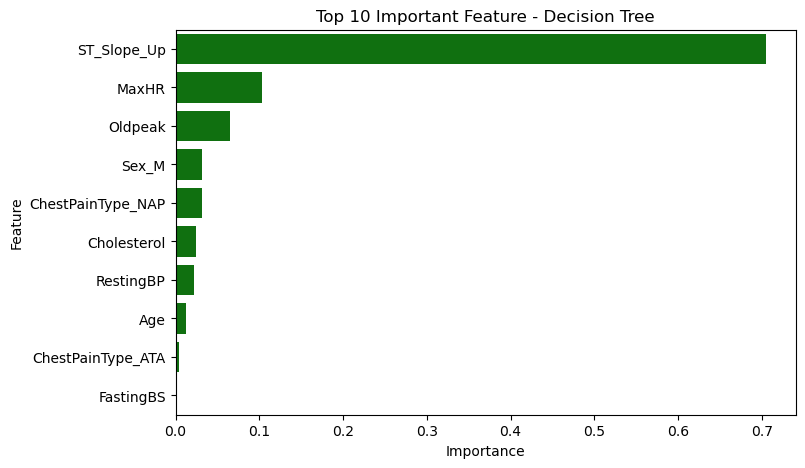

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(data=importance_dt.head(10),x="Importance",y="Feature",color="Green")

plt.title("Top 10 Important Feature - Decision Tree")


## Insights
The Decision Tree model identified **ST_Slope_Up** as the most influential predictor of heart disease, contributing the majority of the model's predictive power. **MaxHR** and **Oldpeak** were the next most important features, highlighting the significance of ECG and exercise-related measurements in prediction.

# Random Forest Model 

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

y_prob_rf=rf.predict_proba(X_test)[:,1]

In [53]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_auc_score)

print("Accuracy:",accuracy_score(y_test,y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test,y_pred_rf))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_rf))

Accuracy: 0.8532608695652174

Confusion Matrix:
[[70 12]
 [15 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84        82
           1       0.88      0.85      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


ROC-AUC: 0.9302367288378767


## Feature Importance

In [54]:
importance_rf=pd.DataFrame({
    'Feature':X_train.columns,
    "Importance":rf.feature_importances_
})


importance_rf=importance_rf.sort_values(by="Importance",ascending = False).head(10)

importance_rf

,Feature,Importance
14,ST_Slope_Up,0.171001
4,MaxHR,0.123020
13,ST_Slope_Flat,0.110290
5,Oldpeak,0.103364
0,Age,0.087082
2,Cholesterol,0.085671
12,ExerciseAngina_Y,0.082705
1,RestingBP,0.074186
7,ChestPainType_ATA,0.036545
6,Sex_M,0.035165


Text(0.5, 1.0, 'Top 10 Important Feature - Random Forest')

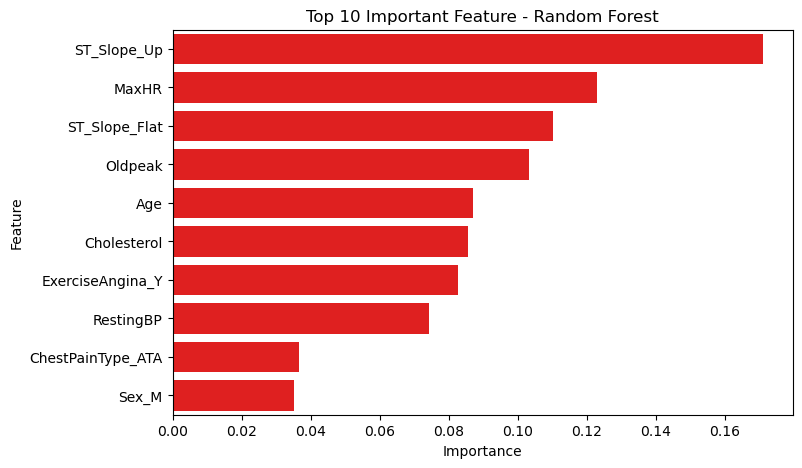

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(data=importance_rf.head(10),x="Importance",y="Feature",color="Red")

plt.title("Top 10 Important Feature - Random Forest")

## Insights 
The Random Forest model identified **ST_Slope_Up, MaxHR, ST_Slope_Flat, and Oldpeak** as the most important predictors of heart disease. This suggests that ECG-related measurements and exercise-induced cardiac responses play a major role in the model's predictions.

## Hyperparameter Tuning

### For ROC-AUC

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf=GridSearchCV(RandomForestClassifier(random_state=42),
        n_jobs=-1,
        param_grid=param_grid,
        cv=5,
        scoring="roc_auc"
    )
grid_rf.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [57]:
print("Best Estimator:",grid_rf.best_estimator_)
print("\nBest Paramater:",grid_rf.best_params_)
print("\nBest Score:",grid_rf.best_score_)

Best Estimator: RandomForestClassifier(max_depth=10, min_samples_leaf=2, n_estimators=300,
                       random_state=42)

Best Paramater: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Best Score: 0.9273319674403686


In [58]:
best_rf=grid_rf.best_estimator_

y_pred_rf_tuned=best_rf.predict(X_test)

y_prob_rf_tuned=best_rf.predict_proba(X_test)[:,1]

In [59]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_rf_tuned))

Accuracy: 0.8641304347826086

Confusion Matrix:
[[71 11]
 [14 88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        82
           1       0.89      0.86      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184


ROC-AUC:
0.930416068866571


## FOR RECALL

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf=GridSearchCV(RandomForestClassifier(random_state=42),
        n_jobs=-1,
        param_grid=param_grid,
        cv=5,
        scoring="recall"
    )
grid_rf.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [61]:
print("Best Estimator:",grid_rf.best_estimator_)
print("\nBest Paramater:",grid_rf.best_params_)
print("\nBest Score:",grid_rf.best_score_)


Best Estimator: RandomForestClassifier(max_depth=7, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

Best Paramater: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

Best Score: 0.916139716952725


In [62]:
best_rf=grid_rf.best_estimator_

y_pred_rf_tuned=best_rf.predict(X_test)

y_prob_rf_tuned=best_rf.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_rf_tuned))

# XGBoost

In [67]:
from xgboost import XGBClassifier

xgb_model=XGBClassifier(random_state=42,eval_metric="logloss")

xgb_model.fit(X_train,y_train)

y_pred_xgb=xgb_model.predict(X_test)
y_prob_xgb=xgb_model.predict_proba(X_test)[:,1]

# Evalution

In [68]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.8369565217391305

Confusion Matrix:
[[70 12]
 [18 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        82
           1       0.88      0.82      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


ROC-AUC:
0.9074605451936871


In [71]:
importance_xgb=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":xgb_model.feature_importances_
})
importance_xgb=importance_xgb.sort_values(by="Importance",ascending=False).head(10)

importance_xgb

,Feature,Importance
14,ST_Slope_Up,0.629638
7,ChestPainType_ATA,0.050153
6,Sex_M,0.046257
8,ChestPainType_NAP,0.043277
3,FastingBS,0.037259
12,ExerciseAngina_Y,0.029976
5,Oldpeak,0.026836
4,MaxHR,0.024989
9,ChestPainType_TA,0.019624
1,RestingBP,0.017782


## Visualization

Text(0.5, 1.0, 'Top 10 Important Features -XGBoost')

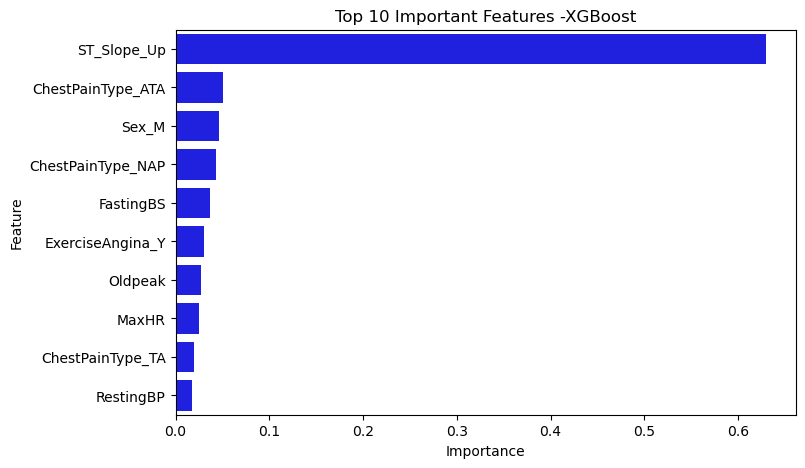

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(data=importance_xgb,x="Importance",y="Feature",color="Blue")
plt.title("Top 10 Important Features -XGBoost")

## Hyperparameter tuning

In [79]:
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

In [80]:
grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [83]:
print("Best Estimator:",grid_xgb.best_estimator_)
print("\nBest Paramater:",grid_xgb.best_params_)
print("\nBest Score:",grid_xgb.best_score_)

Best Estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Best Paramater: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Best Score: 0.92479679710032


In [84]:
best_xgb=grid_xgb.best_estimator_

y_pred_xgb_tuned=best_xgb.predict(X_test)

y_prob_xgb_tuned=best_xgb.predict_proba(X_test)[:,1]

In [86]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_xgb_tuned))

Accuracy: 0.8804347826086957

Confusion Matrix:
[[71 11]
 [11 91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        82
           1       0.89      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184


ROC-AUC:
0.926231468197035


# Comparison Model

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_predict),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],

    "Precision": [
        precision_score(y_test, y_predict),
        precision_score(y_test, y_pred_dt_tuned),
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],

    "Recall": [
        recall_score(y_test, y_predict),
        recall_score(y_test, y_pred_dt_tuned),
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],

    "F1 Score": [
        f1_score(y_test, y_predict),
        f1_score(y_test, y_pred_dt_tuned),
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
})

results = results.round(4)

print("="*70)
print("MODEL COMPARISON TABLE")
print("="*70)

print(results)

print("\n")

best_model = results.loc[
    results["ROC-AUC"].idxmax()
]

print("="*70)
print("BEST MODEL")
print("="*70)

print("Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])
print("ROC-AUC:", best_model["ROC-AUC"])

MODEL COMPARISON TABLE
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8913     0.8942  0.9118    0.9029   0.9341
1        Decision Tree    0.7717     0.7778  0.8235    0.8000   0.8355
2        Random Forest    0.8533     0.8641  0.8725    0.8683   0.9252
3              XGBoost    0.8804     0.8922  0.8922    0.8922   0.9262


BEST MODEL
Model: Logistic Regression
Accuracy: 0.8913
Precision: 0.8942
Recall: 0.9118
F1 Score: 0.9029
ROC-AUC: 0.9341


# Insights

## Model Comparison

Four machine learning models were evaluated for heart disease prediction: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Logistic Regression achieved the best overall performance with an Accuracy of 89.13%, Recall of 91.18%, and ROC-AUC of 0.9341. Since the primary objective of this project is to minimize missed heart disease cases, Recall and ROC-AUC were prioritized during model selection.

Although XGBoost and Random Forest performed competitively, Logistic Regression provided the best balance of predictive performance and interpretability. Therefore, Logistic Regression was selected as the final model.

# Cross Validation

In [99]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,          # Logistic Regression model
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:")
print(cv_scores.mean())

Cross Validation ROC-AUC Scores:
[0.96641651 0.92929293 0.9201272  0.90329218 0.85735992]

Mean ROC-AUC:
0.9152977485226808


### Cross Validation Insight

To evaluate the reliability and generalization ability of the selected Logistic Regression model, 5-fold cross-validation was performed using ROC-AUC as the evaluation metric.

The model achieved a Mean ROC-AUC score of **0.9153**, indicating strong and consistent performance across different data splits. The cross-validation scores remained relatively stable across all folds, suggesting that the model generalizes well to unseen data and is not heavily dependent on a particular train-test split.

These results further validate Logistic Regression as the most suitable model for this heart disease prediction project.

# Conclusion

This project developed a machine learning-based heart disease prediction system using clinical and demographic patient data.

Four machine learning algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, and XGBoost. Model performance was assessed using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Cross Validation.

Among all evaluated models, Logistic Regression achieved the best overall performance with an Accuracy of 89.13%, Recall of 91.18%, ROC-AUC of 0.9341, and a Mean Cross-Validation ROC-AUC score of 0.9153.

Based on these results, Logistic Regression was selected as the final model for heart disease prediction. The findings demonstrate that machine learning can effectively support early disease screening and risk assessment.
